# Agent

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")
# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
llm_with_tools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x0000022056DB4650>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022056DDEBA0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'divide', 'description': 'Divide a and b.', 'parameters': {'properties': {'a': {'description': 'f

In [3]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   print("[sys_msg] + state[messages]::",[sys_msg] +state["messages"])
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

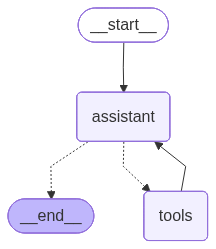

In [4]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})
messages['messages'][-1]

[sys_msg] + state[messages]:: [SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Add 3 and 4. Multiply the output by 2. Divide the output by 5', additional_kwargs={}, response_metadata={}, id='5ebbf526-fcca-41fb-aeb9-ad0f83b30335')]
[sys_msg] + state[messages]:: [SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Add 3 and 4. Multiply the output by 2. Divide the output by 5', additional_kwargs={}, response_metadata={}, id='5ebbf526-fcca-41fb-aeb9-ad0f83b30335'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kmcs24m4d', 'function': {'arguments': '{"a":3,"b":4}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 378, 'total_tokens': 396, 'completion_time': 0.0496

AIMessage(content='The final result is 2.8.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 469, 'total_tokens': 479, 'completion_time': 0.029593693, 'prompt_time': 0.067501779, 'queue_time': 0.076779539, 'total_time': 0.097095472}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--bbd6de11-1163-4e39-9e02-bcc92a2156c5-0', usage_metadata={'input_tokens': 469, 'output_tokens': 10, 'total_tokens': 479})

In [6]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (kmcs24m4d)
 Call ID: kmcs24m4d
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (3vy4gm12d)
 Call ID: 3vy4gm12d
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  divide (m2mxrryws)
 Call ID: m2mxrryws
  Args:
    a: 14
    b: 5
================================= Tool Message =================================
Name: divide

2.8
================================== Ai Message ==================================

T